# NLP Layer – Sentiment, Topic Modeling & Behavioral Intelligence

This notebook implements the NLP intelligence layer of EvaluAI.
It processes open-text employee feedback and enriches the analytical dataset.

If real text data is unavailable, synthetic responses are generated for demonstration.

The pipeline includes:
1. Text validation / synthetic generation
2. Sentiment analysis (pysentimiento)
3. Topic modeling (BERTopic)
4. Behavioral AI Autonomy & Dependency Index
5. Executive insight generation (Gemini)

This pipeline is production-ready and supports real text inputs from the database.

In [1]:
# Import required libraries for data manipulation, plotting, NLP, topic modeling, and utilities.
import os
import json
import urllib.request
import urllib.error

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pysentimiento import create_analyzer
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import MinMaxScaler

# Configure plotting style for readable charts.
sns.set(style='whitegrid')

# Define helper function to locate project root using .env and backend folder presence.
def _find_project_root(start_path: str) -> str:
    """Find project root by walking up until .env and backend directory are found."""
    current = os.path.abspath(start_path)
    while True:
        env_candidate = os.path.join(current, '.env')
        backend_candidate = os.path.join(current, 'backend')
        if os.path.isfile(env_candidate) and os.path.isdir(backend_candidate):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent
    raise ValueError('Could not locate project root containing .env and backend directory.')

# Define helper function to read one key from .env file without external dependencies.
def _read_env_value(env_file: str, key: str) -> str:
    """Read one key from .env file without external dependencies."""
    if not os.path.isfile(env_file):
        return ''
    with open(env_file, 'r', encoding='utf-8') as f:
        for line in f:
            raw = line.strip()
            if not raw or raw.startswith('#') or '=' not in raw:
                continue
            k, v = raw.split('=', 1)
            if k.strip() == key:
                return v.strip().strip('\"').strip("'")
    return ''

# Resolve project paths and dataset location using the same .env strategy as ML notebooks.
project_root = _find_project_root(os.getcwd())
env_path = os.path.join(project_root, '.env')
engineered_data_dir = os.getenv('ENGINEERED_DATA_DIR') or _read_env_value(env_path, 'ENGINEERED_DATA_DIR') or 'backend/data/processed'
if not os.path.isabs(engineered_data_dir):
    engineered_data_dir = os.path.join(project_root, engineered_data_dir)

processed_path = os.path.join(engineered_data_dir, 'survey_engineered.csv')
if not os.path.exists(processed_path):
    raise FileNotFoundError(f'Engineered dataset not found at: {processed_path}')

# Load the engineered survey dataset and print structure information.
df = pd.read_csv(processed_path)
print(f'Dataset loaded from: {processed_path}')
print(f'Dataset shape: {df.shape}')
print('First 30 columns:')
print(df.columns.tolist()[:30])

/home/vscode/.local/lib/python3.11/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


/home/vscode/.local/lib/python3.11/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


Dataset loaded from: /workspaces/EvaluAI/backend/data/processed/survey_engineered.csv
Dataset shape: (100, 58)
First 30 columns:
['id_empleado', 'edad', 'genero', 'departamento', 'antiguedad_empresa', 'nivel_educativo', 'rol_tecnico', 'sector', 'frecuencia_uso_ia', 'usa_chatgpt', 'usa_gemini', 'usa_copilot', 'usa_lms_ia', 'usa_otra_ia', 'herramienta_principal', 'prefiere_humano_vs_ia', 'nivel_integracion_ia', 'AT1_rendimiento', 'AT2_facilita_aprendizaje', 'AT3_facilidad_uso', 'AT4_integracion_positiva', 'AE1_resolver_problemas', 'AE2_confianza_digital', 'AE3_uso_eficaz', 'AE4_seguridad_aplicacion', 'M1_estimulante', 'M2_aumenta_interes', 'M3_aporta_valor', 'M4_mayor_esfuerzo', 'E1_adaptacion']


In [2]:
# Define required open-text columns for NLP processing.
open_text_columns = [
    'open_experience_ai_learning',
    'open_challenges_ai_usage',
    'open_training_needs'
]

# Create missing columns as empty text placeholders to keep pipeline stable.
for column in open_text_columns:
    if column not in df.columns:
        df[column] = np.nan

# Calculate empty ratio per text column considering NaN and blank strings.
empty_ratios = {}
for column in open_text_columns:
    empty_mask = df[column].isna() | (df[column].astype(str).str.strip() == '')
    empty_ratios[column] = float(empty_mask.mean())

# Activate synthetic mode when average emptiness is greater than 80%.
avg_empty_ratio = float(np.mean(list(empty_ratios.values())))
synthetic_text_mode = avg_empty_ratio > 0.80

print('Open-text empty ratios by column:')
for column, ratio in empty_ratios.items():
    print(f'  - {column}: {ratio:.2%}')
print(f'Average empty ratio: {avg_empty_ratio:.2%}')
print(f'synthetic_text_mode: {synthetic_text_mode}')

Open-text empty ratios by column:
  - open_experience_ai_learning: 0.00%
  - open_challenges_ai_usage: 0.00%
  - open_training_needs: 0.00%
Average empty ratio: 0.00%
synthetic_text_mode: False


In [3]:
# Generate synthetic text only when real open-text coverage is insufficient.
if synthetic_text_mode:
    rng = np.random.default_rng(42)

    # Define reusable sentence pools aligned with behavioral rules.
    high_dependency_sentences = [
        'Dependo mucho de las herramientas de IA y me siento inseguro cuando no están disponibles.',
        'Sin apoyo de IA, a veces dudo de mi propio criterio en tareas complejas.'
    ]
    low_dependency_sentences = [
        'Uso la IA como apoyo, pero mantengo decisiones críticas e independientes.',
        'Aunque uso IA, valido los resultados y conservo autonomía en mi trabajo.'
    ]
    neutral_dependency_sentences = [
        'La IA me resulta útil en algunos momentos, pero la combino con experiencia propia.',
        'Mi nivel de dependencia de IA cambia según la complejidad de la tarea y los plazos.'
    ]

    high_motivation_sentences = [
        'Me siento motivado para experimentar y mejorar en cada iteración.',
        'Aprender estas herramientas aumentó mi confianza y mi compromiso.'
    ]
    low_motivation_sentences = [
        'Me siento frustrado porque la curva de aprendizaje sigue siendo exigente.',
        'A veces, la presión por adoptar IA me genera estrés y reduce mi motivación.'
    ]

    high_integration_sentences = [
        'La IA está integrada en mi flujo diario y me ayuda a optimizar tiempos de entrega.',
        'Las sugerencias de automatización me permiten enfocarme en actividades de mayor valor.'
    ]
    low_integration_sentences = [
        'La IA aún no está totalmente integrada en mi rutina y su uso sigue siendo ocasional.',
        'Me beneficiaría contar con una guía más clara para usar IA de forma constante.'
    ]

    # Define helper conversion to robustly parse numeric fields.
    def _to_float(value, default=0.0):
        parsed = pd.to_numeric(pd.Series([value]), errors='coerce').iloc[0]
        if pd.isna(parsed):
            return float(default)
        return float(parsed)

    # Build one coherent paragraph based on profile variables in each row.
    def _generate_paragraph(row):
        dependency_level = str(row.get('dependency_level', 'medium')).strip().lower()
        motivation_score = _to_float(row.get('motivation_score', 0.5), default=0.5)
        integration_level = _to_float(row.get('nivel_integracion_ia', 0.0), default=0.0)
        usage_frequency = _to_float(row.get('frecuencia_uso_ia', 0.0), default=0.0)

        if dependency_level == 'high':
            dependency_sentence = rng.choice(high_dependency_sentences)
        elif dependency_level == 'low':
            dependency_sentence = rng.choice(low_dependency_sentences)
        else:
            dependency_sentence = rng.choice(neutral_dependency_sentences)

        motivation_sentence = rng.choice(high_motivation_sentences) if motivation_score >= 0.5 else rng.choice(low_motivation_sentences)

        # Use practical thresholds that work for both normalized and ordinal scales.
        high_integration = integration_level >= 0.7 or integration_level >= 4
        high_usage = usage_frequency >= 0.7 or usage_frequency >= 4
        integration_sentence = rng.choice(high_integration_sentences) if (high_integration or high_usage) else rng.choice(low_integration_sentences)

        optional_sentences = [
            'La colaboración con mentores y compañeros aceleraría la adopción.',
            'Ejemplos prácticos adaptados a mi rol mejorarían mi confianza.',
            'Sesiones de formación aplicada podrían reducir la incertidumbre en escenarios reales.'
        ]

        # Create coherent 2-4 sentence text with deterministic random behavior.
        base_sentences = [dependency_sentence, motivation_sentence, integration_sentence]
        n_sentences = int(rng.integers(2, 5))
        if n_sentences > len(base_sentences):
            extra = list(rng.choice(optional_sentences, size=n_sentences - len(base_sentences), replace=False))
            final_sentences = base_sentences + extra
        else:
            final_sentences = base_sentences[:n_sentences]

        return ' '.join(final_sentences)

    # Populate all open-text columns with profile-consistent synthetic narratives.
    synthetic_core = df.apply(_generate_paragraph, axis=1)
    df['open_experience_ai_learning'] = 'Experiencia de aprendizaje: ' + synthetic_core
    df['open_challenges_ai_usage'] = 'Principal desafío: ' + synthetic_core
    df['open_training_needs'] = 'Necesidad de formación: ' + synthetic_core

    # Save updates back to engineered dataset path for reproducibility.
    df.to_csv(processed_path, index=False)
    print(f'Synthetic text generated and saved to: {processed_path}')
    print(df[open_text_columns].head(5).to_string(index=False))
else:
    # Keep original open text when sufficient real coverage exists.
    print('Synthetic text mode disabled. Existing open-text data is used.')
    print(df[open_text_columns].head(5).to_string(index=False))

Synthetic text mode disabled. Existing open-text data is used.
                                                                                                                                                                                                                                                                                                                         open_experience_ai_learning                                                                                                                                                                                                                                                                                                                    open_challenges_ai_usage                                                                                                                                                                                                                                                                         

In [4]:
# Build a unified NLP text field from the three open-text columns.
df['full_text'] = (
    df['open_experience_ai_learning'].fillna('') + ' ' +
    df['open_challenges_ai_usage'].fillna('') + ' ' +
    df['open_training_needs'].fillna('')
)

# Apply basic cleaning: lowercase, strip whitespace, and collapse repeated spaces.
df['full_text'] = (
    df['full_text']
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)

print('Sample full_text values:')
print(df['full_text'].head(5).to_string(index=False))

Sample full_text values:
experiencia de aprendizaje: uso la ia como apoy...
experiencia de aprendizaje: la ia me resulta út...
experiencia de aprendizaje: uso la ia como apoy...
experiencia de aprendizaje: mi nivel de depende...
experiencia de aprendizaje: mi nivel de depende...


Sentiment analyzer loaded with language: es


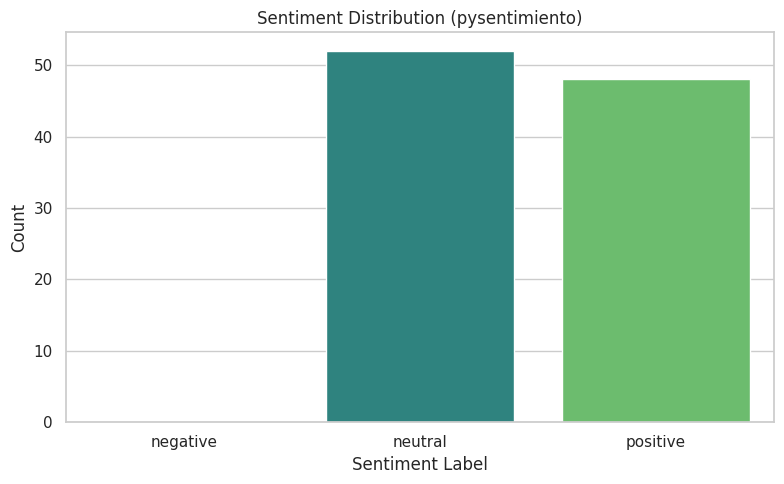

Sentiment label distribution:
sentiment_label
neutral     52
positive    48
Name: count, dtype: int64


In [5]:
# Initialize multilingual sentiment analyzer with fallback strategy.
sentiment_analyzer = None
for lang in ['es', 'en']:
    try:
        sentiment_analyzer = create_analyzer(task='sentiment', lang=lang)
        print(f'Sentiment analyzer loaded with language: {lang}')
        break
    except Exception:
        continue

if sentiment_analyzer is None:
    raise RuntimeError('Could not initialize pysentimiento sentiment analyzer for es or en.')

# Define label normalization and scoring map for consistent numeric sentiment score.
label_map = {
    'pos': 'positive',
    'positive': 'positive',
    'neu': 'neutral',
    'neutral': 'neutral',
    'neg': 'negative',
    'negative': 'negative'
}
score_map = {
    'negative': 0.0,
    'neutral': 0.5,
    'positive': 1.0
}

# Run sentiment prediction for each text and store label, score, and confidence.
sentiment_labels = []
sentiment_scores = []
sentiment_confidences = []

for text in df['full_text'].fillna('').astype(str):
    if text.strip() == '':
        sentiment_labels.append('neutral')
        sentiment_scores.append(0.5)
        sentiment_confidences.append(0.0)
        continue

    prediction = sentiment_analyzer.predict(text)
    raw_label = str(prediction.output).strip().lower()
    normalized_label = label_map.get(raw_label, 'neutral')

    probas = prediction.probas if hasattr(prediction, 'probas') else {}
    confidence = float(max(probas.values())) if probas else 0.0

    sentiment_labels.append(normalized_label)
    sentiment_scores.append(float(score_map[normalized_label]))
    sentiment_confidences.append(confidence)

df['sentiment_label'] = sentiment_labels
df['sentiment_score'] = sentiment_scores
df['sentiment_confidence'] = sentiment_confidences

# Plot sentiment distribution as requested.
plt.figure(figsize=(8, 5))
sentiment_order = ['negative', 'neutral', 'positive']
sns.countplot(data=df, x='sentiment_label', order=sentiment_order, palette='viridis')
plt.title('Sentiment Distribution (pysentimiento)')
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print('Sentiment label distribution:')
print(df['sentiment_label'].value_counts(dropna=False))

Top 5 topics:
 Topic  Count                   Name
     0     55          0_mi_en_la_ia
     1     24       1_de_en_la_valor
     2     21 2_de_la_mi_dependencia
Top keywords per topic:
  - Topic 0: ['mi', 'en', 'la', 'ia', 'me', 'de', 'experiencia', 'pero']
  - Topic 1: ['de', 'en', 'la', 'valor', 'permiten', 'automatizacin', 'las', 'enfocarme']
  - Topic 2: ['de', 'la', 'mi', 'dependencia', 'tarea', 'nivel', 'complejidad', 'cambia']


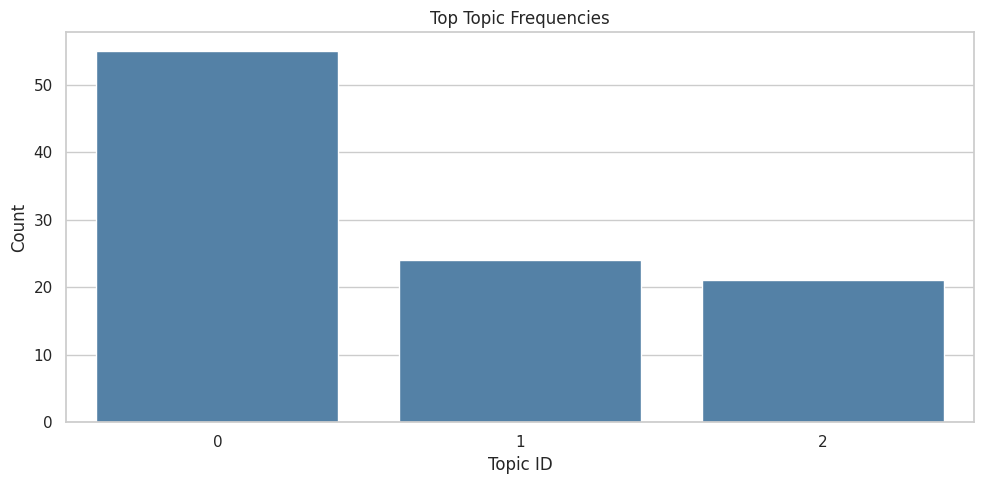

In [6]:
# Build sentence embedding model for BERTopic on multilingual text.
embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Prepare text corpus and precompute embeddings explicitly.
texts = df['full_text'].fillna('').astype(str).tolist()
embeddings = embedding_model.encode(texts, show_progress_bar=False)

# Initialize BERTopic with requested random_state and fallback for version compatibility.
try:
    topic_model = BERTopic(
        random_state=42,
        calculate_probabilities=True,
        verbose=False
    )
except TypeError:
    topic_model = BERTopic(
        calculate_probabilities=True,
        verbose=False
    )

# Fit topic model using precomputed embeddings and collect topic assignments and probabilities.
topics, topic_probabilities = topic_model.fit_transform(texts, embeddings)
df['topic_id'] = topics

# Compute maximum topic probability per row when probabilities are available.
if topic_probabilities is not None and hasattr(topic_probabilities, 'shape'):
    df['topic_probability'] = np.max(topic_probabilities, axis=1).astype(float)
else:
    df['topic_probability'] = np.nan

# Display top 5 non-outlier topics and representative keywords.
topic_info = topic_model.get_topic_info()
top_topics = topic_info[topic_info['Topic'] != -1].head(5).copy()
print('Top 5 topics:')
print(top_topics[['Topic', 'Count', 'Name']].to_string(index=False))

print('Top keywords per topic:')
for topic_id in top_topics['Topic'].tolist():
    words = topic_model.get_topic(int(topic_id))
    keywords = [w for w, _ in words[:8]] if words else []
    print(f'  - Topic {topic_id}: {keywords}')

# Plot topic frequency distribution excluding outlier topic -1.
topic_counts = df[df['topic_id'] != -1]['topic_id'].value_counts().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=topic_counts.index.astype(str), y=topic_counts.values, color='steelblue')
plt.title('Top Topic Frequencies')
plt.xlabel('Topic ID')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Topic vs sentiment crosstab:
sentiment_label  neutral  positive
topic_id                          
0                     24        31
1                     12        12
2                     16         5


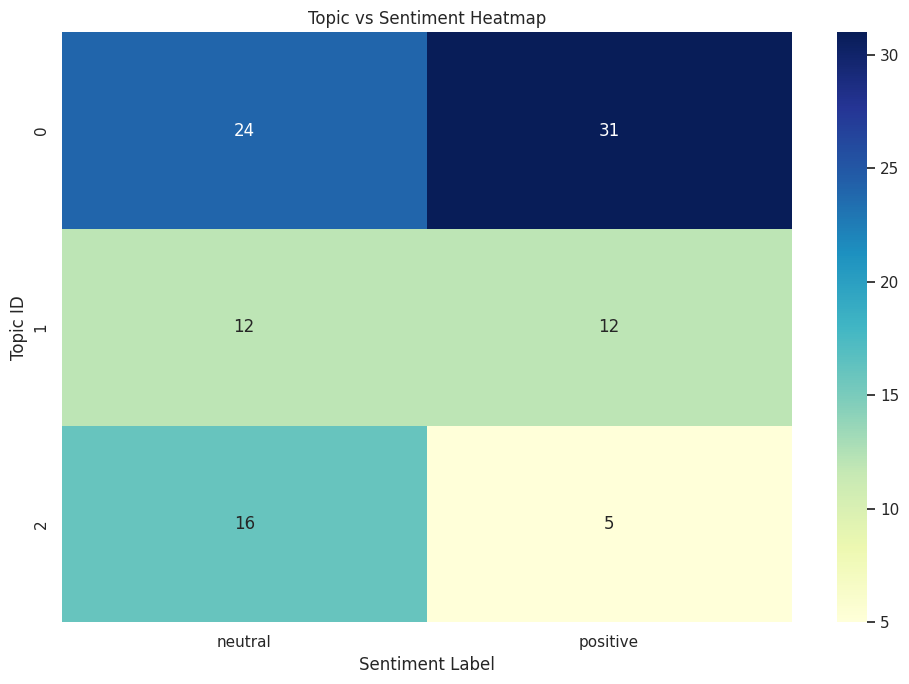

In [7]:
# Build topic vs sentiment contingency table.
topic_sentiment_ct = pd.crosstab(df['topic_id'], df['sentiment_label'])
print('Topic vs sentiment crosstab:')
print(topic_sentiment_ct.head(15).to_string())

# Plot heatmap to inspect alignment between discovered themes and sentiment polarity.
plt.figure(figsize=(10, 7))
sns.heatmap(topic_sentiment_ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Topic vs Sentiment Heatmap')
plt.xlabel('Sentiment Label')
plt.ylabel('Topic ID')
plt.tight_layout()
plt.show()

In [ ]:
# Normalize sentiment score to [0, 1] using MinMaxScaler.
scaler = MinMaxScaler(feature_range=(0, 1))
df['sentiment_norm'] = scaler.fit_transform(df[['sentiment_score']]).ravel()

# Define lexical risk and autonomy keyword sets for behavioral scoring.
risk_keywords = ['struggle', 'confused', 'lack', 'depend', 'lost']
autonomy_keywords = ['confident', 'independent', 'autonomous', 'creative', 'improve']

# Compute keyword-based score as fraction of keyword matches per text.
def _keyword_fraction(text: str, keywords: list) -> float:
    lower_text = str(text).lower()
    matches = sum(1 for kw in keywords if kw in lower_text)
    return float(matches / len(keywords)) if keywords else 0.0

df['topic_risk_score'] = df['full_text'].apply(lambda t: _keyword_fraction(t, risk_keywords))
df['autonomy_signal_score'] = df['full_text'].apply(lambda t: _keyword_fraction(t, autonomy_keywords))

# Build AI Autonomy & Dependency Index (NPI) using the provided weighted formula.
df['ai_autonomy_dependency_index'] = (
    0.4 * df['sentiment_norm'] +
    0.3 * (1 - df['topic_risk_score']) +
    0.3 * df['autonomy_signal_score']
)

# Categorize NPI into healthy, moderate_risk, and high_risk bands.
conditions = [
    df['ai_autonomy_dependency_index'] > 0.7,
    (df['ai_autonomy_dependency_index'] >= 0.4) & (df['ai_autonomy_dependency_index'] <= 0.7),
    df['ai_autonomy_dependency_index'] < 0.4
]
choices = ['healthy', 'moderate_risk', 'high_risk']
df['ai_autonomy_dependency_category'] = np.select(conditions, choices, default='moderate_risk')

print('AI Autonomy & Dependency Category distribution:')
print(df['ai_autonomy_dependency_category'].value_counts(dropna=False))

AI Autonomy & Dependency Category distribution:
ai_autonomy_dependency_category
high_risk        52
moderate_risk    48
Name: count, dtype: int64


In [9]:
# Resolve Gemini credentials and model configuration from environment or .env file.
gemini_api_key = (
    os.getenv('GEMINI_API_KEY')
    or _read_env_value(env_path, 'GEMINI_API_KEY')
    or os.getenv('CHATBOT_GEMINI_API_KEY')
    or _read_env_value(env_path, 'CHATBOT_GEMINI_API_KEY')
)
gemini_model = os.getenv('CHATBOT_GEMINI_MODEL') or _read_env_value(env_path, 'CHATBOT_GEMINI_MODEL') or 'gemini-2.5-flash'

# Build executive context from sentiment, topic, and NPI outputs.
sentiment_distribution = df['sentiment_label'].value_counts(normalize=True).round(3).to_dict()
npi_distribution = df['ai_autonomy_dependency_category'].value_counts(normalize=True).round(3).to_dict()
top_5_topics_summary = top_topics[['Topic', 'Count', 'Name']].to_dict(orient='records') if 'top_topics' in globals() else []
representative_texts = df['full_text'].dropna().astype(str).loc[lambda s: s.str.strip() != ''].sample(n=min(3, len(df)), random_state=42).tolist()

# Compose a structured prompt for executive-level interpretation.
prompt = f"""
You are an HR analytics executive assistant for EvaluAI.
Generate a concise executive summary with: 
1) Key sentiment insights
2) Dominant discussion topics
3) Behavioral risk implications from NPI
4) Recommended leadership actions

Sentiment distribution: {json.dumps(sentiment_distribution, ensure_ascii=False)}
Top 5 topics: {json.dumps(top_5_topics_summary, ensure_ascii=False)}
NPI distribution: {json.dumps(npi_distribution, ensure_ascii=False)}
Representative employee texts: {json.dumps(representative_texts, ensure_ascii=False)}
""".strip()

# Call Gemini API when key is available; otherwise create a simulated summary.
if gemini_api_key:
    try:
        api_url = f'https://generativelanguage.googleapis.com/v1beta/models/{gemini_model}:generateContent?key={gemini_api_key}'
        payload = {
            'contents': [
                {'parts': [{'text': prompt}]}
            ],
            'generationConfig': {
                'temperature': 0.2
            }
        }
        request_data = json.dumps(payload).encode('utf-8')
        request = urllib.request.Request(
            api_url,
            data=request_data,
            headers={'Content-Type': 'application/json'},
            method='POST'
        )
        with urllib.request.urlopen(request, timeout=30) as response:
            response_json = json.loads(response.read().decode('utf-8'))

        executive_summary = (
            response_json.get('candidates', [{}])[0]
            .get('content', {})
            .get('parts', [{}])[0]
            .get('text', '')
        )

        if not executive_summary.strip():
            raise ValueError('Gemini returned an empty summary.')

    except Exception as exc:
        executive_summary = (
            'Executive Summary (Simulated fallback):\n'
            '- Sentiment suggests mixed employee experience with opportunities for targeted coaching.\n'
            '- Dominant topics indicate practical AI adoption barriers and workflow adaptation needs.\n'
            '- NPI profile highlights moderate behavioral risk concentration in specific groups.\n'
            '- Recommended actions: role-based enablement, manager coaching, and autonomy-building training.\n'
            f'- Gemini API fallback reason: {exc}'
        )
else:
    executive_summary = (
        'Executive Summary (Simulated):\n'
        '- Sentiment distribution indicates pockets of positive engagement with notable neutral/negative segments.\n'
        '- Top topics suggest recurring friction around trust, adoption confidence, and integration quality.\n'
        '- NPI categories reveal where behavioral reinforcement is needed before structural KPIs deteriorate.\n'
        '- Recommended actions: mentoring pathways, practical use-case workshops, and leadership follow-up cadence.'
    )

# Store and print executive summary output.
df['executive_summary'] = executive_summary
print('===== EXECUTIVE INSIGHT =====')
print(executive_summary)

===== EXECUTIVE INSIGHT =====
**Executive Summary: AI Integration & Employee Well-being**

**1) Key Sentiment Insights:**
Sentiment is evenly split between neutral (52%) and positive (48%), indicating a generally receptive but not strongly enthusiastic employee base regarding AI integration. No negative sentiment was detected.

**2) Dominant Discussion Topics:**
The primary discussions revolve around employees' personal interaction and integration with AI ("mi en la ia"), the perceived value derived from AI, and critically, their level of dependency on AI ("mi dependencia").

**3) Behavioral Risk Implications from NPI:**
A significant concern is the high AI Autonomy & Dependency (NPI) risk, with 52% of employees categorized as high-risk and 48% as moderate-risk. This widespread risk suggests challenges related to potential over-reliance on AI, maintaining professional autonomy, and balancing AI assistance with personal expertise and critical thinking. Employee comments highlight varyin

In [10]:
# Define required enriched output columns to ensure expected NLP outputs are present.
required_nlp_columns = [
    'sentiment_label',
    'sentiment_score',
    'topic_id',
    'topic_risk_score',
    'autonomy_signal_score',
    'ai_autonomy_dependency_index',
    'ai_autonomy_dependency_category'
]

missing_nlp_columns = [c for c in required_nlp_columns if c not in df.columns]
if missing_nlp_columns:
    raise ValueError(f'Missing required NLP columns before saving: {missing_nlp_columns}')

# Save enriched dataset into the processed directory.
enriched_output_path = os.path.join(engineered_data_dir, 'survey_nlp_enriched.csv')
df.to_csv(enriched_output_path, index=False)

print(f'NLP-enriched dataset saved to: {enriched_output_path}')
print(f'Output shape: {df.shape}')
print('Preview of required NLP columns:')
print(df[required_nlp_columns].head(5).to_string(index=False))

NLP-enriched dataset saved to: /workspaces/EvaluAI/backend/data/processed/survey_nlp_enriched.csv
Output shape: (100, 70)
Preview of required NLP columns:
sentiment_label  sentiment_score  topic_id  topic_risk_score  autonomy_signal_score  ai_autonomy_dependency_index ai_autonomy_dependency_category
       positive              1.0         1               0.2                    0.0                     0.64              moderate_risk
       positive              1.0         0               0.0                    0.0                     0.70              moderate_risk
        neutral              0.5         1               0.2                    0.0                     0.24                  high_risk
        neutral              0.5         2               0.2                    0.0                     0.24                  high_risk
        neutral              0.5         1               0.2                    0.0                     0.24                  high_risk


## Business Interpretation

Sentiment distribution indicates the emotional climate of AI adoption, including confidence, neutrality, and frustration pockets.

Dominant topics suggest what employees repeatedly discuss, revealing structural friction points and enablement opportunities.

The AI Autonomy & Dependency Index adds a behavioral signal that goes beyond structural predictors by combining affect, risk language, and autonomy cues from real text.

This intelligence layer connects directly to:
- dropout risk (behavioral disengagement can anticipate attrition intent),
- dependency (language reveals over-reliance or autonomous use patterns),
- ROI perception (tone and topics contextualize perceived training value).

This NLP layer provides behavioral intelligence that complements structural machine learning models.